# Análisis Exploratorio y Preprocesamiento de Radiografías

**Universidad Nacional de Colombia**  
Visión por Computador 3009228 - Semestre 2025-02  
Facultad de Minas - Departamento de Ciencias de la Computación y de la Decisión

---

## Contenido

**Parte 1: Análisis Exploratorio**
1. Carga y visualización de datos
2. Distribución de clases
3. Análisis de dimensiones
4. Análisis de intensidades

**Parte 2: Preprocesamiento**

5. Normalización de tamaño
6. Ecualización CLAHE (`apply_clahe_enhancement`)
7. Segmentación de pulmones (`segment_lung_region`)
8. Pipeline completo

---

## 1. Configuración del Entorno

In [8]:
# Importar librerías
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path
import sys
import warnings

warnings.filterwarnings('ignore')

# Agregar src al path
sys.path.insert(0, '../src')

# Importar módulos del proyecto
from data_loader import DataLoader
from preprocessing import XRayPreprocessor
from utils import load_image, save_results

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


In [9]:
# Configuración de rutas
DATA_ROOT = Path('../data/chest-xray-pneumonia/chest_xray')
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Verificar dataset
if not DATA_ROOT.exists():
    print(f"⚠️ Dataset no encontrado en {DATA_ROOT}")
    print("Descargar de: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia")
else:
    print(f"✓ Dataset encontrado en {DATA_ROOT}")

✓ Dataset encontrado en ../data/chest-xray-pneumonia/chest_xray


In [10]:
# Inicializar cargador de datos
loader = DataLoader(DATA_ROOT)
image_paths = loader.get_image_paths()

print("✓ DataLoader inicializado")

✓ DataLoader inicializado


---

# PARTE 1: ANÁLISIS EXPLORATORIO

---

## 2. Distribución de Clases

In [11]:
# Obtener conteos
class_counts = loader.get_class_counts()

# Tabla de distribución
print("=" * 55)
print("DISTRIBUCIÓN DE CLASES")
print("=" * 55)
print(f"{'Split':<10} {'NORMAL':>10} {'PNEUMONIA':>12} {'Total':>10} {'Ratio':>10}")
print("-" * 55)

for split in ['train', 'val', 'test']:
    if split in class_counts:
        normal = class_counts[split].get('NORMAL', 0)
        pneumonia = class_counts[split].get('PNEUMONIA', 0)
        total = normal + pneumonia
        ratio = pneumonia / normal if normal > 0 else 0
        print(f"{split:<10} {normal:>10} {pneumonia:>12} {total:>10} {ratio:>10.2f}")

print("=" * 55)

DISTRIBUCIÓN DE CLASES
Split          NORMAL    PNEUMONIA      Total      Ratio
-------------------------------------------------------
train            1341         3875       5216       2.89
val                 8            8         16       1.00
test              234          390        624       1.67


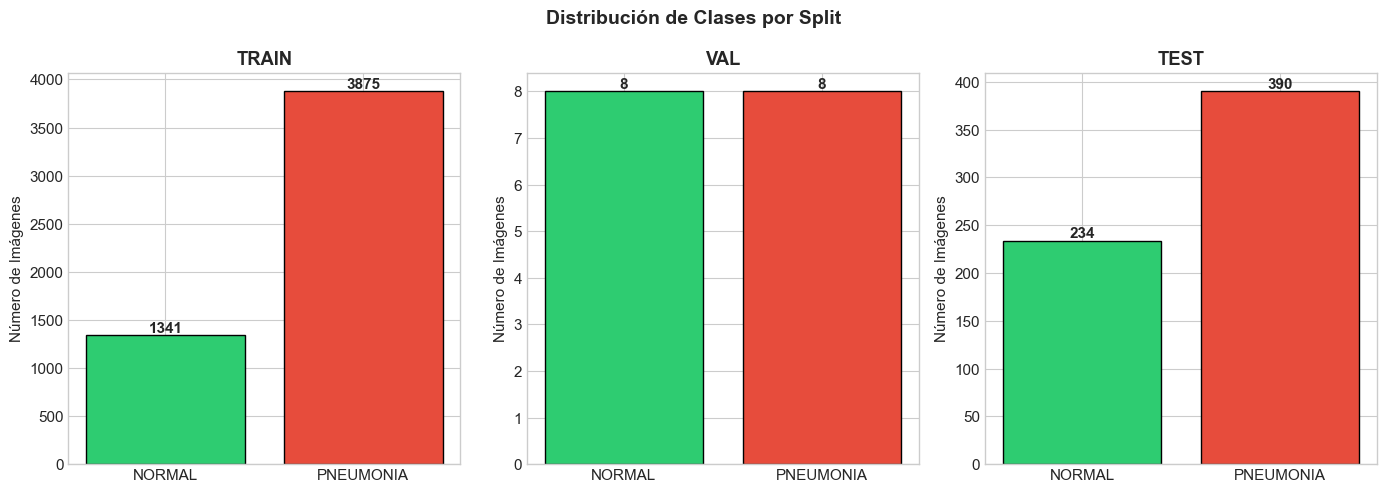

In [12]:
# Visualización de distribución
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Distribución de Clases por Split', fontsize=14, fontweight='bold')

colors = ['#2ecc71', '#e74c3c']

for idx, split in enumerate(['train', 'val', 'test']):
    if split in class_counts:
        counts = class_counts[split]
        bars = axes[idx].bar(counts.keys(), counts.values(), color=colors, edgecolor='black')
        axes[idx].set_title(f'{split.upper()}', fontweight='bold')
        axes[idx].set_ylabel('Número de Imágenes')
        
        for bar, count in zip(bars, counts.values()):
            axes[idx].annotate(f'{count}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Visualización de Muestras

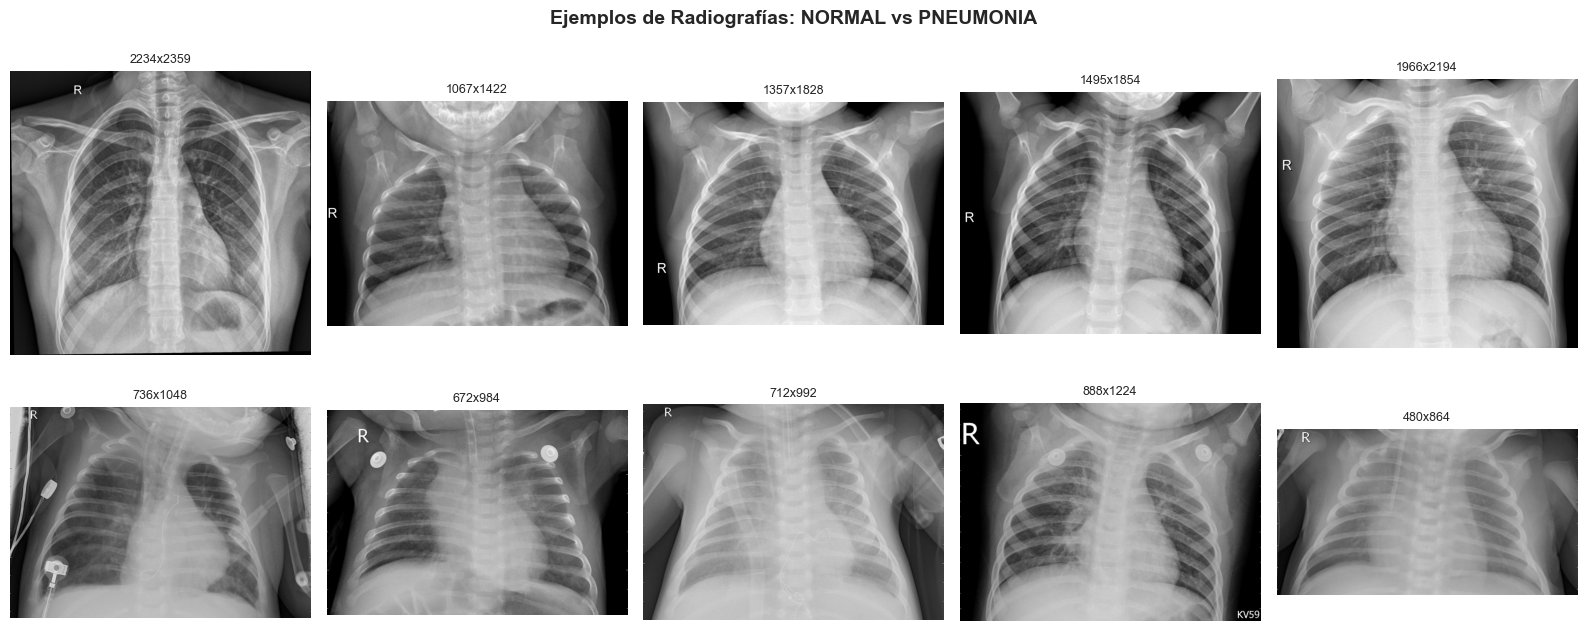

In [13]:
# Obtener muestras
samples = loader.get_sample_images(split='train', n_per_class=5)

# Visualizar
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Ejemplos de Radiografías: NORMAL vs PNEUMONIA', fontsize=14, fontweight='bold')

for i, class_name in enumerate(['NORMAL', 'PNEUMONIA']):
    for j, img in enumerate(samples[class_name][:5]):
        if img is not None:
            axes[i, j].imshow(img, cmap='gray')
            axes[i, j].axis('off')
            axes[i, j].set_title(f'{img.shape[0]}x{img.shape[1]}', fontsize=9)
    axes[i, 0].set_ylabel(class_name, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Análisis de Dimensiones

In [14]:
# Estadísticas de dimensiones
dim_stats = loader.analyze_dimensions(n_samples=100)

print("=" * 50)
print("ESTADÍSTICAS DE DIMENSIONES")
print("=" * 50)
print(f"Altura:  {dim_stats['mean_height']:.0f} ± {dim_stats['std_height']:.0f} px")
print(f"Ancho:   {dim_stats['mean_width']:.0f} ± {dim_stats['std_width']:.0f} px")
print(f"Rango:   [{dim_stats['min_height']}, {dim_stats['max_height']}] x [{dim_stats['min_width']}, {dim_stats['max_width']}]")
print("=" * 50)
print("\n→ Conclusión: Necesario normalizar tamaño a 224x224")

ESTADÍSTICAS DE DIMENSIONES
Altura:  1086 ± 444 px
Ancho:   1447 ± 413 px
Rango:   [127, 2663] x [384, 2720]

→ Conclusión: Necesario normalizar tamaño a 224x224


## 5. Análisis de Intensidades

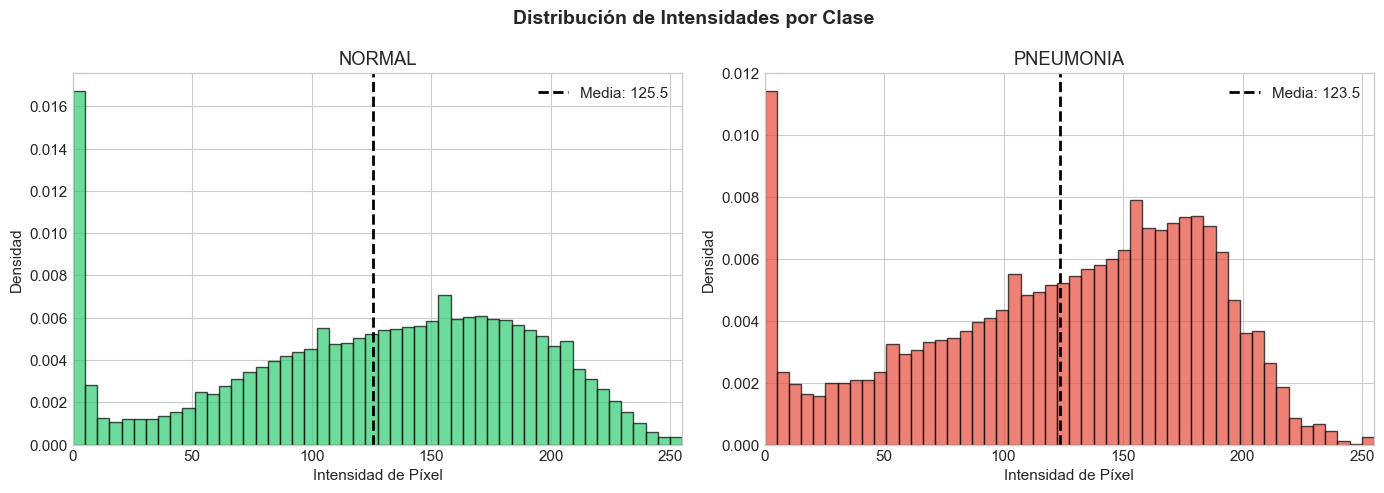

In [15]:
# Recolectar intensidades por clase
intensity_data = {'NORMAL': [], 'PNEUMONIA': []}

for class_name in ['NORMAL', 'PNEUMONIA']:
    for path in image_paths['train'][class_name][:30]:
        img = loader.load_image(path)
        if img is not None:
            intensity_data[class_name].extend(img.flatten()[::50].tolist())

# Visualizar distribuciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Intensidades por Clase', fontsize=14, fontweight='bold')

colors = {'NORMAL': '#2ecc71', 'PNEUMONIA': '#e74c3c'}

for idx, class_name in enumerate(['NORMAL', 'PNEUMONIA']):
    axes[idx].hist(intensity_data[class_name], bins=50, density=True, 
                   alpha=0.7, color=colors[class_name], edgecolor='black')
    axes[idx].set_xlabel('Intensidad de Píxel')
    axes[idx].set_ylabel('Densidad')
    axes[idx].set_title(class_name)
    axes[idx].set_xlim([0, 255])
    
    mean_val = np.mean(intensity_data[class_name])
    axes[idx].axvline(mean_val, color='black', linestyle='--', linewidth=2,
                     label=f'Media: {mean_val:.1f}')
    axes[idx].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'intensity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---

# PARTE 2: PREPROCESAMIENTO

---

## 6. Ecualización CLAHE (`apply_clahe_enhancement`)

### Fundamentos Teóricos

**CLAHE (Contrast Limited Adaptive Histogram Equalization)** mejora el contraste local de imágenes.

#### ¿Por qué CLAHE para radiografías?

| Característica | Ecualización Global | CLAHE |
|----------------|---------------------|-------|
| Procesamiento | Imagen completa | Por regiones (tiles) |
| Ruido | Amplifica excesivamente | Controlado por clipLimit |
| Detalles locales | Se pierden | Se preservan |
| Uso en radiografías | No recomendado | **Recomendado** |

#### Parámetros:
- **clipLimit** (2.0-4.0): Limita amplificación del contraste
- **tileGridSize** (8x8): Tamaño de regiones para ecualización local

In [16]:
# Cargar imagen de ejemplo
sample_img = loader.load_image(image_paths['train']['PNEUMONIA'][5])
print(f"Imagen original: {sample_img.shape}, dtype: {sample_img.dtype}")

Imagen original: (584, 944), dtype: uint8


In [17]:
# Crear preprocesador para usar apply_clahe_enhancement
preprocessor = XRayPreprocessor(
    target_size=(256, 256),
    apply_clahe=True,
    clahe_clip_limit=2.0,
    clahe_tile_grid=(8, 8),
    segment_lungs=False,
    normalize=False
)

# Redimensionar primero
img_resized = preprocessor.resize(sample_img)

# Aplicar CLAHE usando el método del preprocesador
img_clahe = preprocessor.apply_clahe_enhancement(img_resized)

print(f"Imagen con CLAHE: {img_clahe.shape}, dtype: {img_clahe.dtype}")

Imagen con CLAHE: (256, 256), dtype: uint8


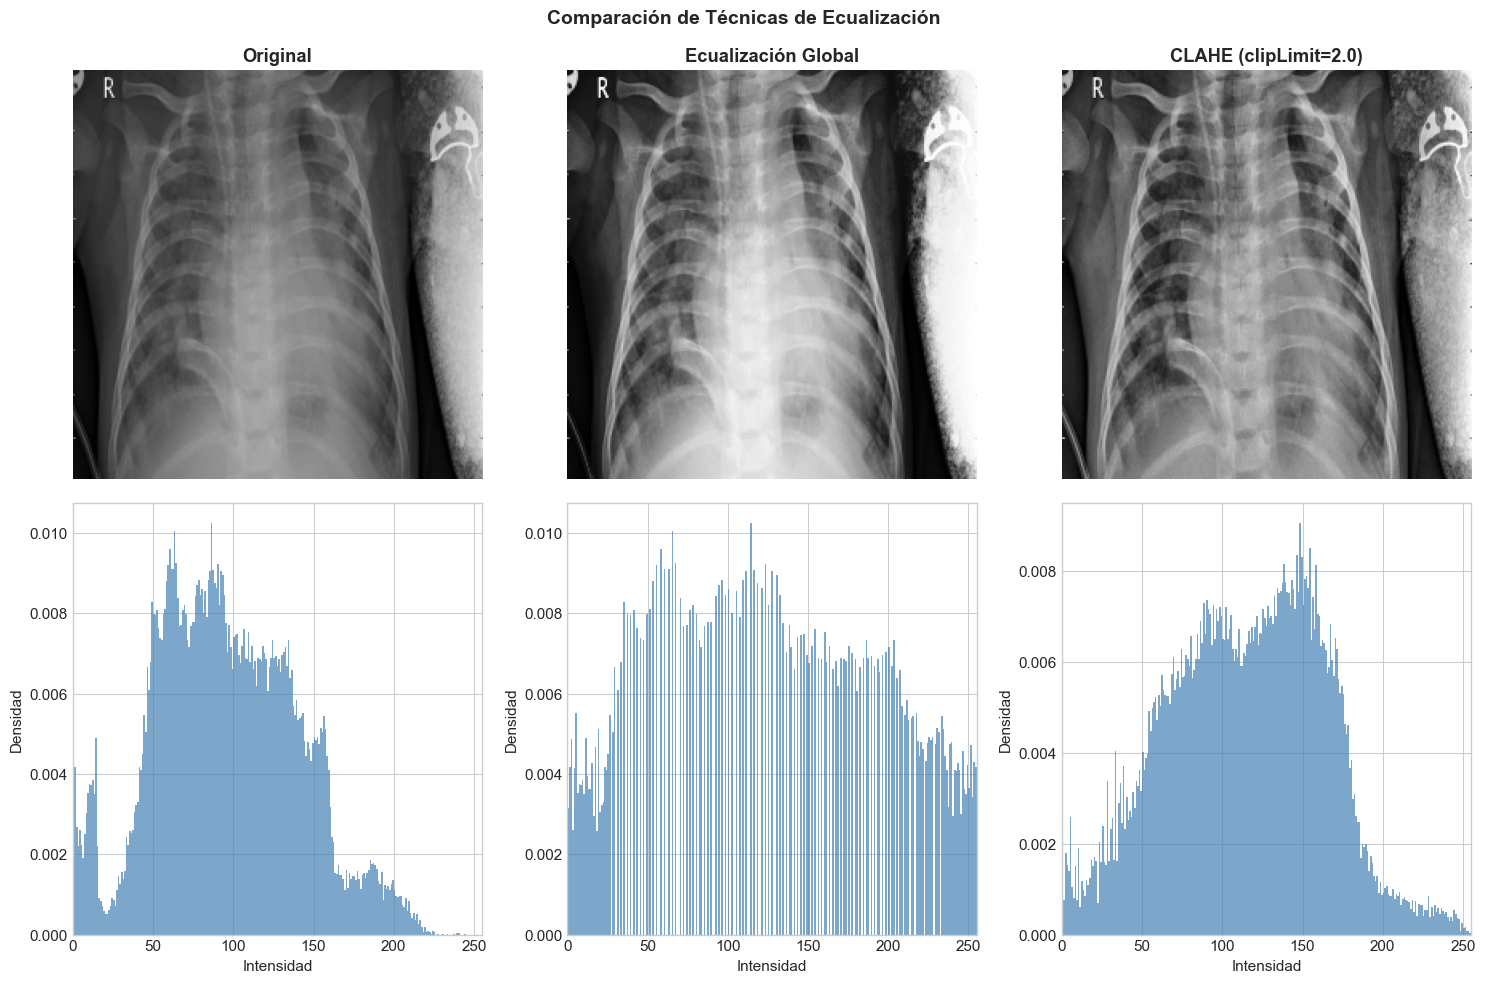

In [18]:
# Comparar: Original vs Ecualización Global vs CLAHE
img_eq_global = cv2.equalizeHist(img_resized)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Comparación de Técnicas de Ecualización', fontsize=14, fontweight='bold')

images = [img_resized, img_eq_global, img_clahe]
titles = ['Original', 'Ecualización Global', 'CLAHE (clipLimit=2.0)']

for idx, (img, title) in enumerate(zip(images, titles)):
    # Imagen
    axes[0, idx].imshow(img, cmap='gray')
    axes[0, idx].set_title(title, fontweight='bold')
    axes[0, idx].axis('off')
    
    # Histograma
    axes[1, idx].hist(img.flatten(), bins=256, range=(0, 256), 
                      density=True, alpha=0.7, color='steelblue', edgecolor='none')
    axes[1, idx].set_xlabel('Intensidad')
    axes[1, idx].set_ylabel('Densidad')
    axes[1, idx].set_xlim([0, 255])

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'clahe_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Efecto de parámetros CLAHE

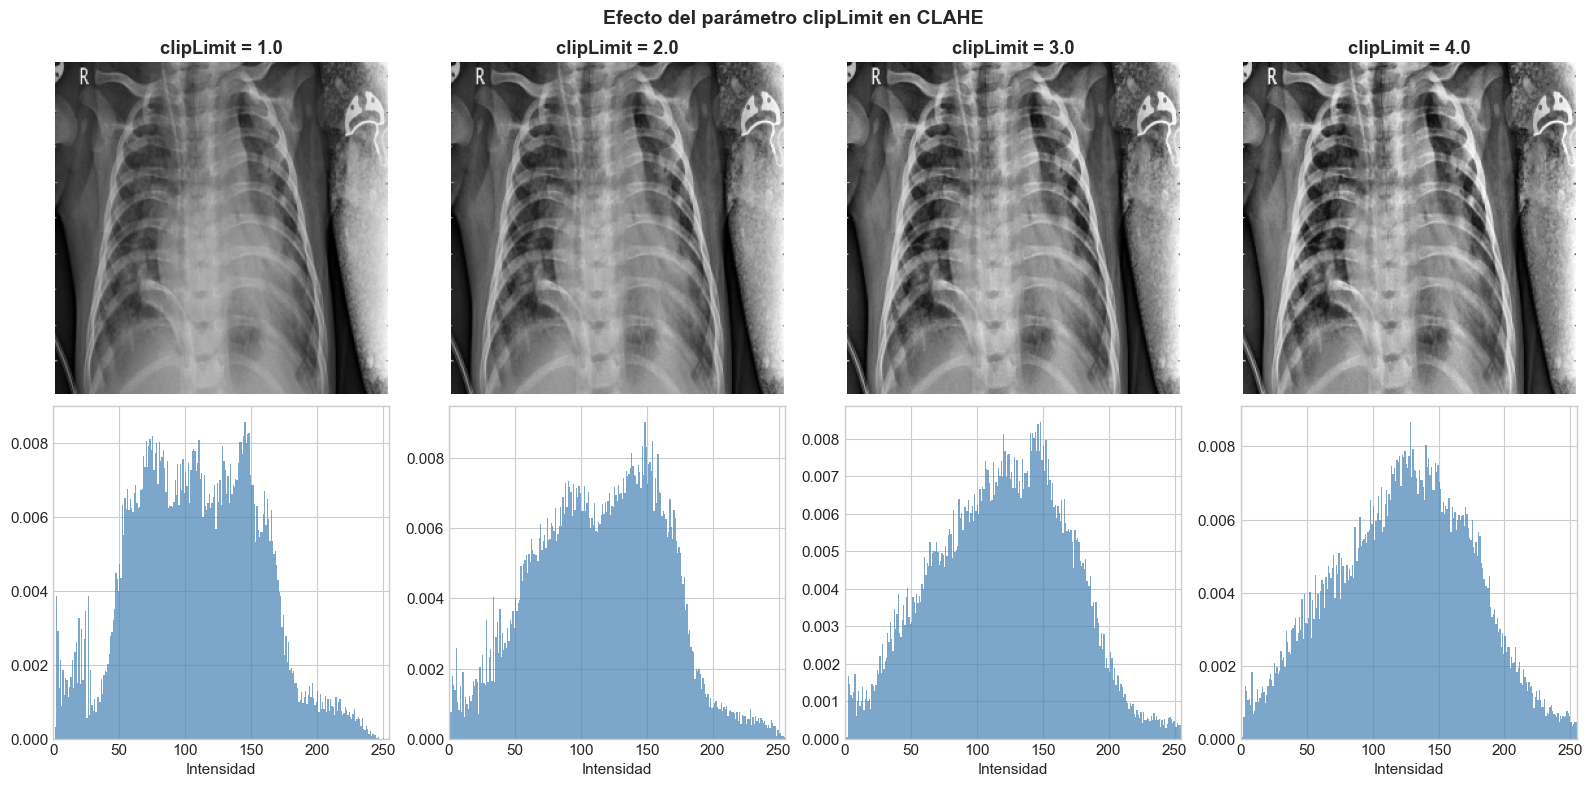


→ Conclusión: clipLimit=2.0 ofrece buen balance entre contraste y control de ruido


In [19]:
# Comparar diferentes valores de clipLimit
clip_limits = [1.0, 2.0, 3.0, 4.0]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Efecto del parámetro clipLimit en CLAHE', fontsize=14, fontweight='bold')

for idx, clip in enumerate(clip_limits):
    # Crear CLAHE con diferente clipLimit
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(8, 8))
    img_result = clahe.apply(img_resized)
    
    # Imagen
    axes[0, idx].imshow(img_result, cmap='gray')
    axes[0, idx].set_title(f'clipLimit = {clip}', fontweight='bold')
    axes[0, idx].axis('off')
    
    # Histograma
    axes[1, idx].hist(img_result.flatten(), bins=256, range=(0, 256),
                      density=True, alpha=0.7, color='steelblue')
    axes[1, idx].set_xlabel('Intensidad')
    axes[1, idx].set_xlim([0, 255])

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'clahe_cliplimit_effect.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n→ Conclusión: clipLimit=2.0 ofrece buen balance entre contraste y control de ruido")

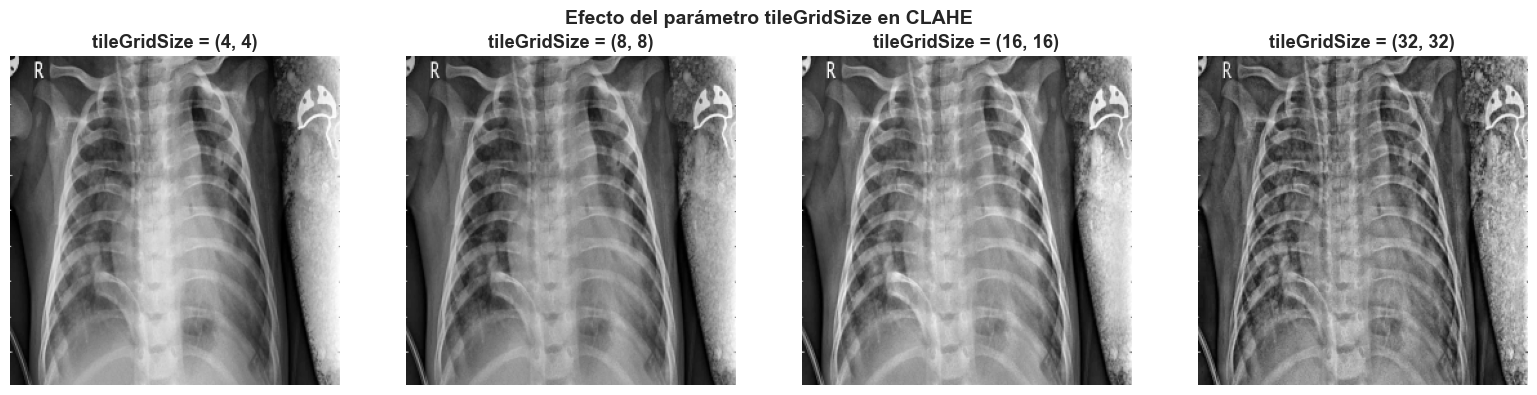


→ Conclusión: tileGridSize=(8,8) es el estándar para radiografías


In [20]:
# Comparar diferentes tileGridSize
tile_sizes = [(4, 4), (8, 8), (16, 16), (32, 32)]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Efecto del parámetro tileGridSize en CLAHE', fontsize=14, fontweight='bold')

for idx, tile in enumerate(tile_sizes):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=tile)
    img_result = clahe.apply(img_resized)
    
    axes[idx].imshow(img_result, cmap='gray')
    axes[idx].set_title(f'tileGridSize = {tile}', fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'clahe_tilesize_effect.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n→ Conclusión: tileGridSize=(8,8) es el estándar para radiografías")

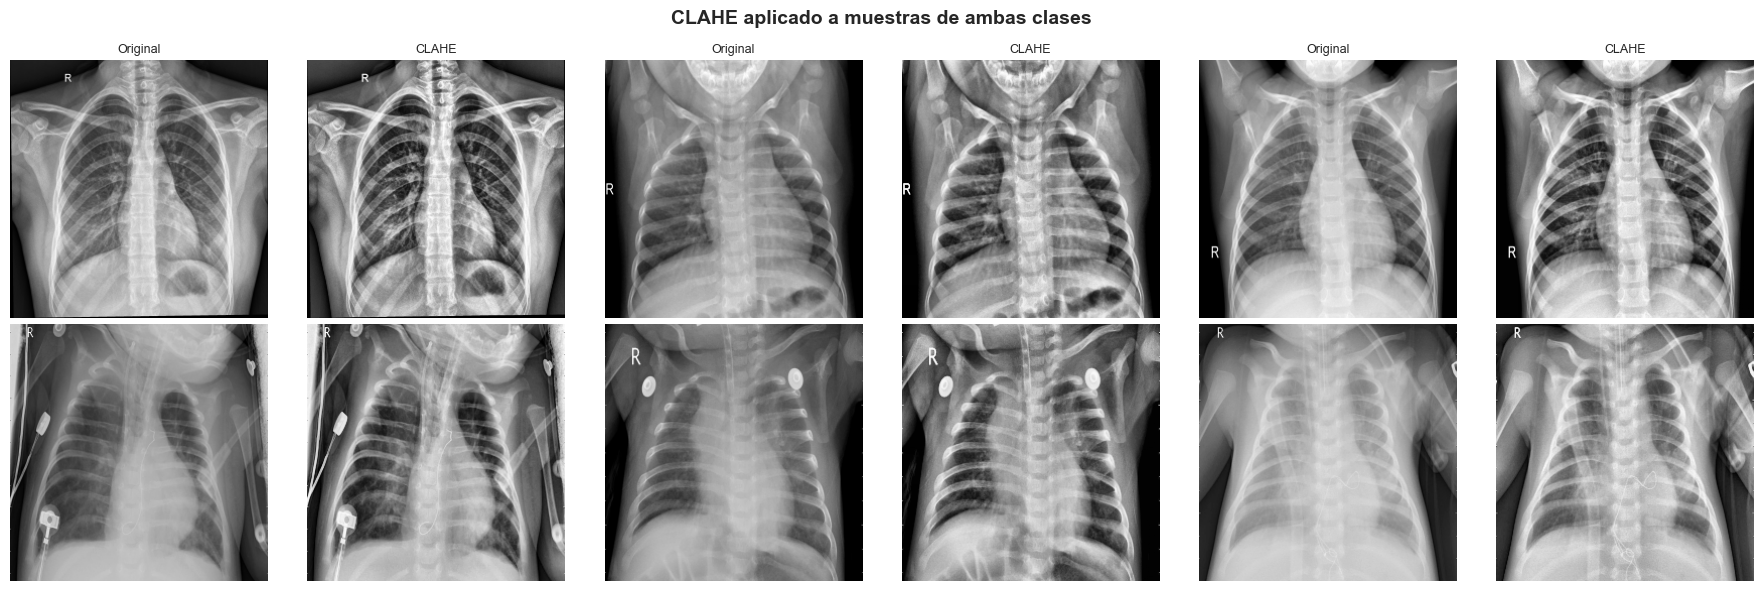

In [21]:
# Aplicar CLAHE a múltiples imágenes de ambas clases
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle('CLAHE aplicado a muestras de ambas clases', fontsize=14, fontweight='bold')

for row, class_name in enumerate(['NORMAL', 'PNEUMONIA']):
    paths = image_paths['train'][class_name][:3]
    
    for col, path in enumerate(paths):
        img = loader.load_image(path)
        img_res = preprocessor.resize(img)
        img_clahe = preprocessor.apply_clahe_enhancement(img_res)
        
        # Original
        axes[row, col*2].imshow(img_res, cmap='gray')
        axes[row, col*2].set_title('Original' if row == 0 else '', fontsize=9)
        axes[row, col*2].axis('off')
        
        # CLAHE
        axes[row, col*2+1].imshow(img_clahe, cmap='gray')
        axes[row, col*2+1].set_title('CLAHE' if row == 0 else '', fontsize=9)
        axes[row, col*2+1].axis('off')
    
    axes[row, 0].set_ylabel(class_name, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'clahe_samples.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 7. Segmentación de Pulmones (`segment_lung_region`)

### Fundamentos

La segmentación de pulmones aísla la región de interés (ROI) eliminando:
- Bordes de la imagen
- Texto y anotaciones
- Estructuras óseas (costillas, columna)

### Algoritmo implementado:
1. Umbralización con Otsu
2. Inversión (pulmones son oscuros)
3. Operaciones morfológicas (apertura/cierre)
4. Selección de los 2 componentes más grandes
5. Creación de máscara combinada

In [22]:
# Cargar imagen para segmentación
sample_img = loader.load_image(image_paths['train']['NORMAL'][10])
img_resized = preprocessor.resize(sample_img)
img_clahe = preprocessor.apply_clahe_enhancement(img_resized)

print(f"Imagen preparada: {img_clahe.shape}")

Imagen preparada: (256, 256)


In [23]:
# Aplicar segmentación usando el método del preprocesador
img_segmented, mask = preprocessor.segment_lung_region(img_clahe)

print(f"Imagen segmentada: {img_segmented.shape}")
print(f"Máscara: {mask.shape}, valores únicos: {np.unique(mask)}")

Imagen segmentada: (256, 256)
Máscara: (256, 256), valores únicos: [  0 255]


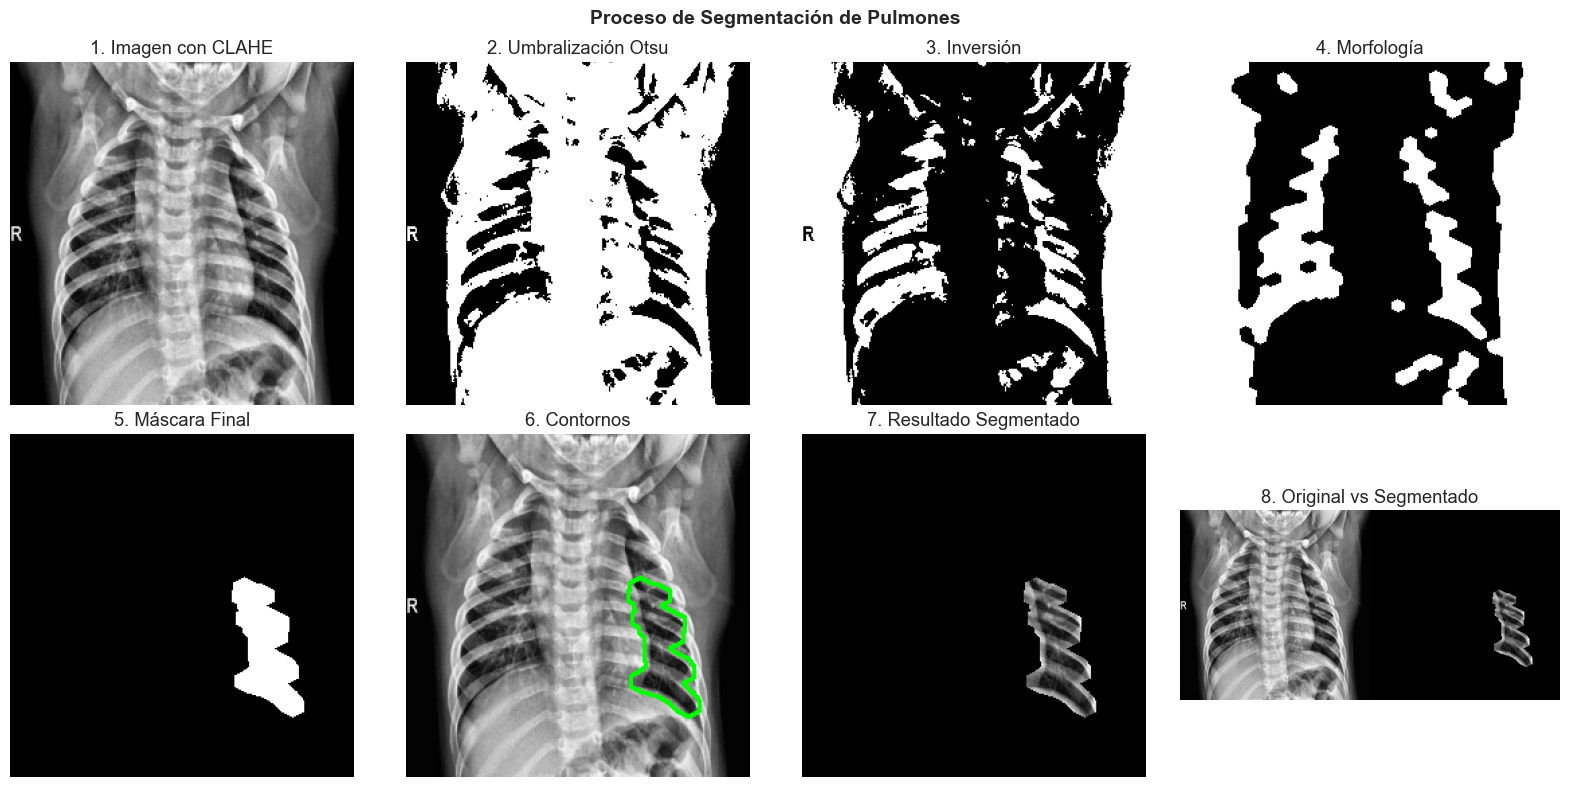

In [24]:
# Visualizar proceso de segmentación paso a paso
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Proceso de Segmentación de Pulmones', fontsize=14, fontweight='bold')

# Paso 1: Imagen original con CLAHE
axes[0, 0].imshow(img_clahe, cmap='gray')
axes[0, 0].set_title('1. Imagen con CLAHE')
axes[0, 0].axis('off')

# Paso 2: Umbralización Otsu
_, binary = cv2.threshold(img_clahe, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
axes[0, 1].imshow(binary, cmap='gray')
axes[0, 1].set_title('2. Umbralización Otsu')
axes[0, 1].axis('off')

# Paso 3: Inversión
binary_inv = cv2.bitwise_not(binary)
axes[0, 2].imshow(binary_inv, cmap='gray')
axes[0, 2].set_title('3. Inversión')
axes[0, 2].axis('off')

# Paso 4: Operaciones morfológicas
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
morph = cv2.morphologyEx(binary_inv, cv2.MORPH_CLOSE, kernel, iterations=2)
morph = cv2.morphologyEx(morph, cv2.MORPH_OPEN, kernel, iterations=2)
axes[0, 3].imshow(morph, cmap='gray')
axes[0, 3].set_title('4. Morfología')
axes[0, 3].axis('off')

# Paso 5: Máscara final
axes[1, 0].imshow(mask, cmap='gray')
axes[1, 0].set_title('5. Máscara Final')
axes[1, 0].axis('off')

# Paso 6: Contorno sobre imagen original
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
img_contour = cv2.cvtColor(img_clahe, cv2.COLOR_GRAY2RGB)
cv2.drawContours(img_contour, contours, -1, (0, 255, 0), 2)
axes[1, 1].imshow(img_contour)
axes[1, 1].set_title('6. Contornos')
axes[1, 1].axis('off')

# Paso 7: Imagen segmentada
axes[1, 2].imshow(img_segmented, cmap='gray')
axes[1, 2].set_title('7. Resultado Segmentado')
axes[1, 2].axis('off')

# Paso 8: Comparación lado a lado
combined = np.hstack([img_clahe, img_segmented])
axes[1, 3].imshow(combined, cmap='gray')
axes[1, 3].set_title('8. Original vs Segmentado')
axes[1, 3].axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'segmentation_process.png', dpi=150, bbox_inches='tight')
plt.show()

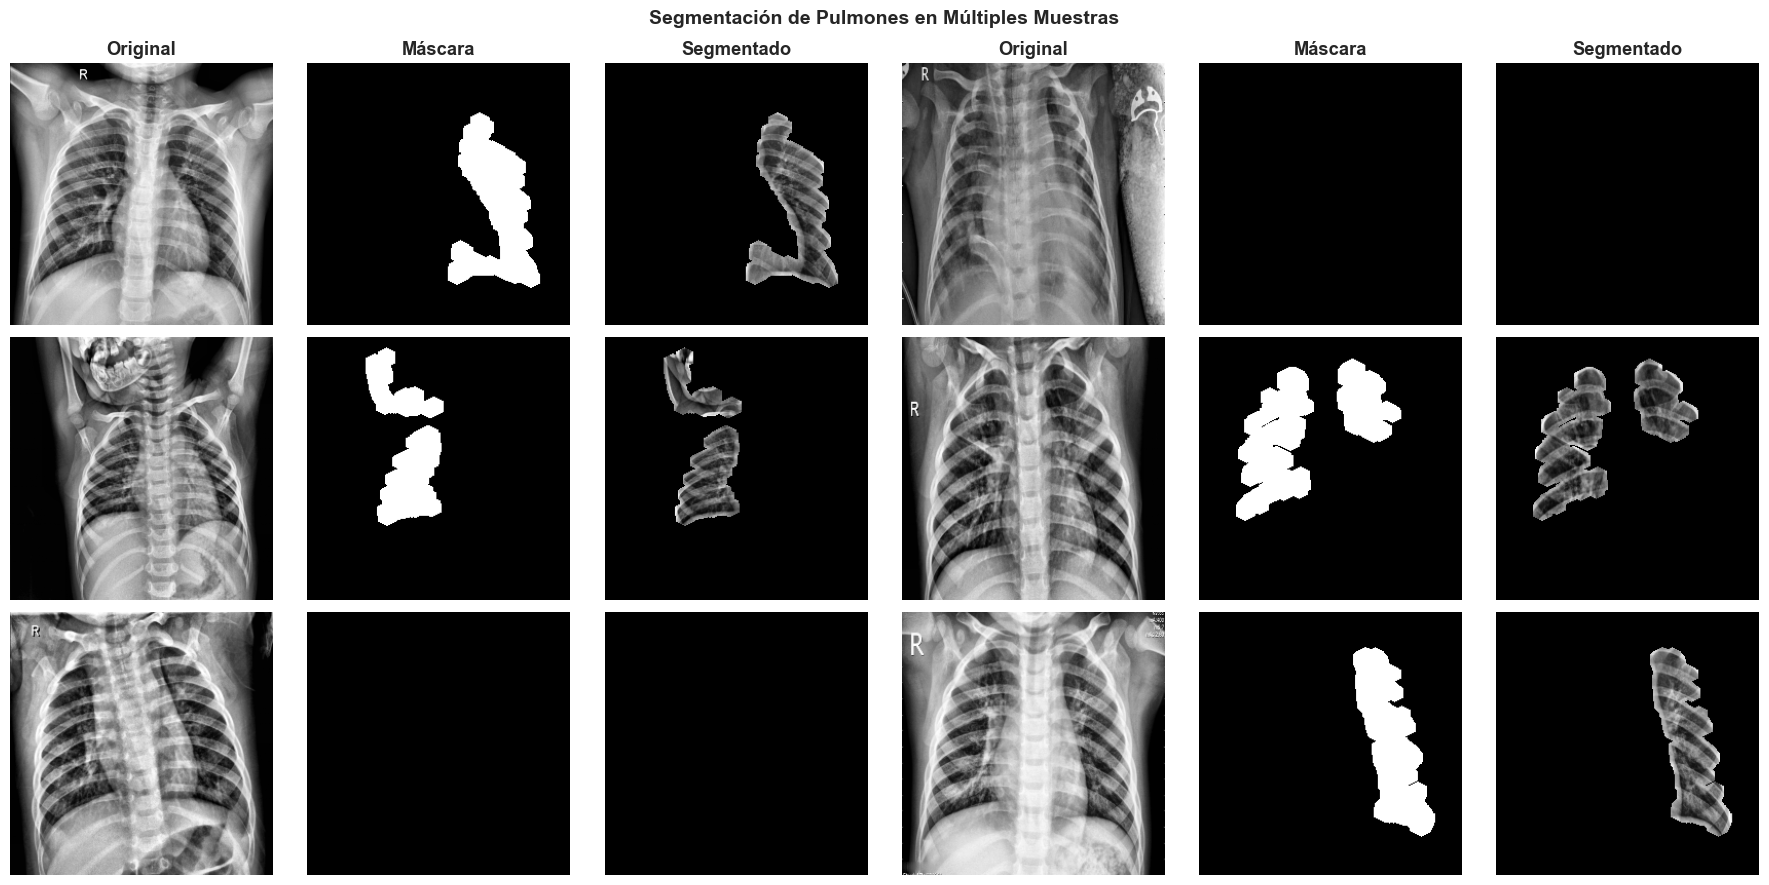

In [25]:
# Aplicar segmentación a múltiples imágenes
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle('Segmentación de Pulmones en Múltiples Muestras', fontsize=14, fontweight='bold')

# Columnas: Original, Máscara, Segmentado (x2 clases)
col_titles = ['Original', 'Máscara', 'Segmentado', 'Original', 'Máscara', 'Segmentado']
for j, title in enumerate(col_titles):
    axes[0, j].set_title(title, fontweight='bold')

for row in range(3):
    for class_idx, class_name in enumerate(['NORMAL', 'PNEUMONIA']):
        path = image_paths['train'][class_name][row + 5]
        img = loader.load_image(path)
        img_res = preprocessor.resize(img)
        img_clahe = preprocessor.apply_clahe_enhancement(img_res)
        img_seg, mask = preprocessor.segment_lung_region(img_clahe)
        
        col_offset = class_idx * 3
        
        axes[row, col_offset].imshow(img_clahe, cmap='gray')
        axes[row, col_offset].axis('off')
        
        axes[row, col_offset + 1].imshow(mask, cmap='gray')
        axes[row, col_offset + 1].axis('off')
        
        axes[row, col_offset + 2].imshow(img_seg, cmap='gray')
        axes[row, col_offset + 2].axis('off')

# Etiquetas de clase
axes[1, 0].set_ylabel('NORMAL', fontsize=12, fontweight='bold', rotation=0, labelpad=50)
axes[1, 3].set_ylabel('PNEUMONIA', fontsize=12, fontweight='bold', rotation=0, labelpad=60)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'segmentation_samples.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 8. Pipeline Completo de Preprocesamiento

In [26]:
# Crear preprocesador con pipeline completo
full_preprocessor = XRayPreprocessor(
    target_size=(224, 224),
    apply_clahe=True,
    clahe_clip_limit=2.0,
    clahe_tile_grid=(8, 8),
    segment_lungs=False,  # Opcional
    normalize=True
)

print("Pipeline de preprocesamiento configurado:")
print(f"  1. Redimensionar a {full_preprocessor.target_size}")
print(f"  2. CLAHE (clipLimit={full_preprocessor.clahe_clip_limit})")
print(f"  3. Segmentación: {full_preprocessor.segment_lungs}")
print(f"  4. Normalización [0,1]: {full_preprocessor.normalize}")

Pipeline de preprocesamiento configurado:
  1. Redimensionar a (224, 224)
  2. CLAHE (clipLimit=2.0)
  3. Segmentación: False
  4. Normalización [0,1]: True


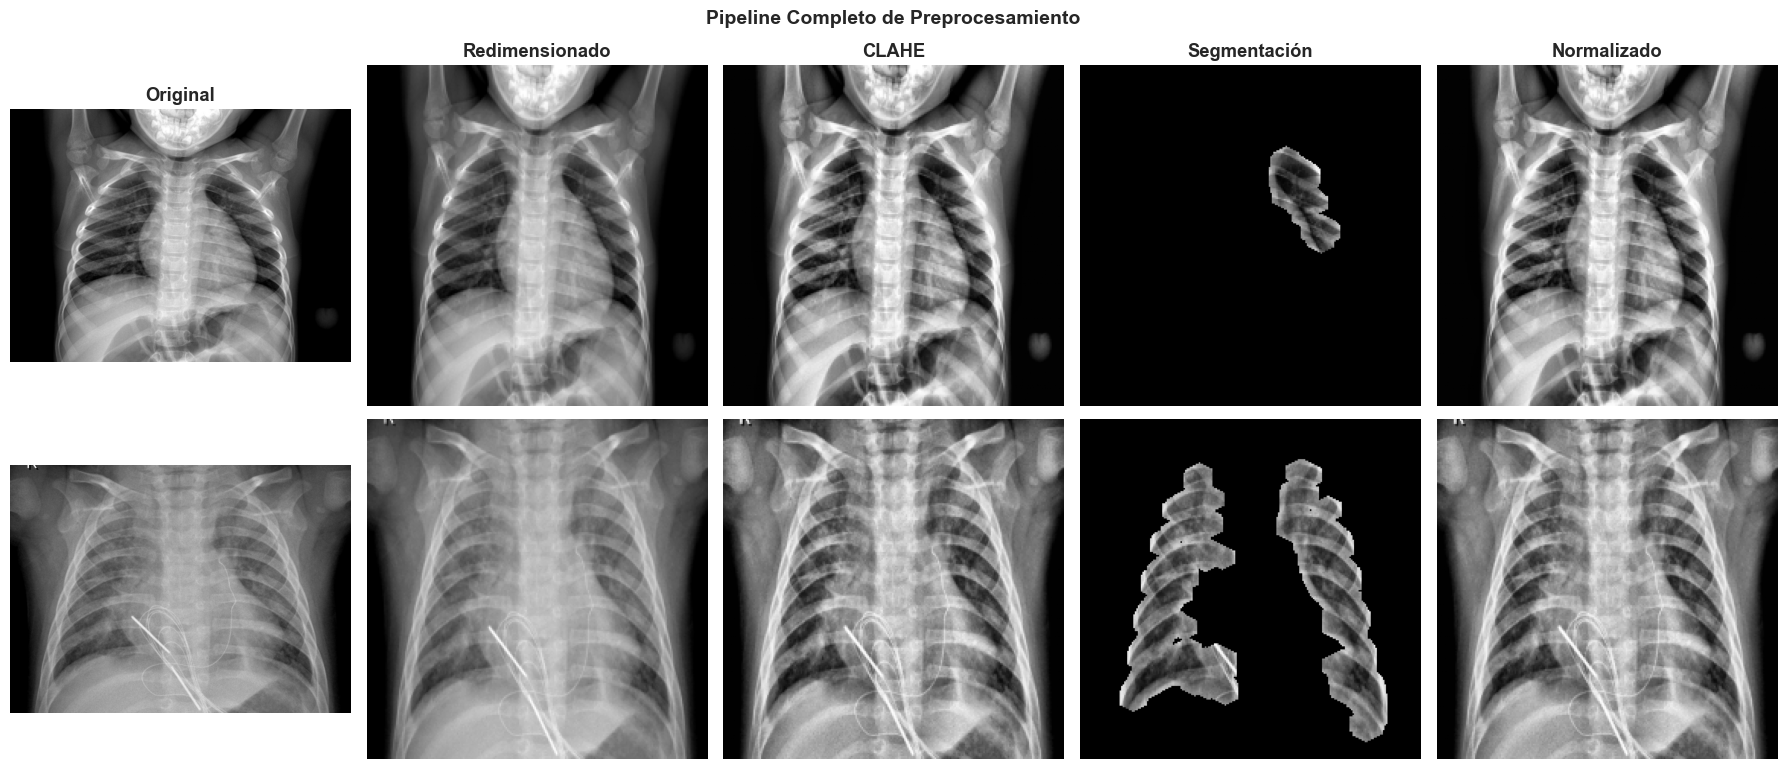

In [27]:
# Visualizar pipeline completo
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('Pipeline Completo de Preprocesamiento', fontsize=14, fontweight='bold')

steps = ['Original', 'Redimensionado', 'CLAHE', 'Segmentación', 'Normalizado']
for j, title in enumerate(steps):
    axes[0, j].set_title(title, fontweight='bold')

for row, class_name in enumerate(['NORMAL', 'PNEUMONIA']):
    path = image_paths['train'][class_name][15]
    img_original = loader.load_image(path)
    
    # Paso 1: Original
    axes[row, 0].imshow(img_original, cmap='gray')
    axes[row, 0].axis('off')
    axes[row, 0].set_ylabel(class_name, fontsize=12, fontweight='bold')
    
    # Paso 2: Redimensionado
    img_resized = full_preprocessor.resize(img_original)
    axes[row, 1].imshow(img_resized, cmap='gray')
    axes[row, 1].axis('off')
    
    # Paso 3: CLAHE
    img_clahe = full_preprocessor.apply_clahe_enhancement(img_resized)
    axes[row, 2].imshow(img_clahe, cmap='gray')
    axes[row, 2].axis('off')
    
    # Paso 4: Segmentación
    img_seg, _ = full_preprocessor.segment_lung_region(img_clahe)
    axes[row, 3].imshow(img_seg, cmap='gray')
    axes[row, 3].axis('off')
    
    # Paso 5: Normalizado (usando CLAHE, no segmentación por defecto)
    img_normalized = full_preprocessor.normalize_image(img_clahe)
    axes[row, 4].imshow(img_normalized, cmap='gray')
    axes[row, 4].axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'full_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# Procesar batch de imágenes con el método preprocess
sample_paths = image_paths['train']['PNEUMONIA'][:5]
images_raw = [loader.load_image(p) for p in sample_paths]

# Usar preprocess_batch
images_processed = full_preprocessor.preprocess_batch(images_raw)

print(f"Batch procesado: {images_processed.shape}")
print(f"Rango de valores: [{images_processed.min():.3f}, {images_processed.max():.3f}]")
print(f"Dtype: {images_processed.dtype}")

Batch procesado: (5, 224, 224)
Rango de valores: [0.004, 1.000]
Dtype: float32


---

## 9. Resumen y Conclusiones

In [29]:
print("=" * 70)
print("RESUMEN DEL ANÁLISIS Y PREPROCESAMIENTO")
print("=" * 70)

print("\n📊 ANÁLISIS EXPLORATORIO:")
print("   • Dataset desbalanceado (ratio ~2.9:1 en train)")
print("   • Dimensiones variables → necesario normalizar")
print("   • Diferencias sutiles en intensidades entre clases")

print("\n🔧 PREPROCESAMIENTO IMPLEMENTADO:")
print("   • Redimensionamiento a 224x224 (estándar para CNNs)")
print("   • CLAHE (clipLimit=2.0, tileGrid=8x8) para mejorar contraste")
print("   • Segmentación de pulmones (opcional) para aislar ROI")
print("   • Normalización [0,1] para estabilidad numérica")

print("\n✅ CONFIGURACIÓN RECOMENDADA:")
print("   XRayPreprocessor(")
print("       target_size=(224, 224),")
print("       apply_clahe=True,")
print("       clahe_clip_limit=2.0,")
print("       clahe_tile_grid=(8, 8),")
print("       segment_lungs=False,")
print("       normalize=True")
print("   )")

print("\n" + "=" * 70)

RESUMEN DEL ANÁLISIS Y PREPROCESAMIENTO

📊 ANÁLISIS EXPLORATORIO:
   • Dataset desbalanceado (ratio ~2.9:1 en train)
   • Dimensiones variables → necesario normalizar
   • Diferencias sutiles en intensidades entre clases

🔧 PREPROCESAMIENTO IMPLEMENTADO:
   • Redimensionamiento a 224x224 (estándar para CNNs)
   • CLAHE (clipLimit=2.0, tileGrid=8x8) para mejorar contraste
   • Segmentación de pulmones (opcional) para aislar ROI
   • Normalización [0,1] para estabilidad numérica

✅ CONFIGURACIÓN RECOMENDADA:
   XRayPreprocessor(
       target_size=(224, 224),
       apply_clahe=True,
       clahe_clip_limit=2.0,
       clahe_tile_grid=(8, 8),
       segment_lungs=False,
       normalize=True
   )



In [30]:
# Guardar configuración y estadísticas
results = {
    'exploratory': {
        'class_counts': class_counts,
        'dimension_stats': dim_stats
    },
    'preprocessing': {
        'target_size': [224, 224],
        'clahe_clip_limit': 2.0,
        'clahe_tile_grid': [8, 8],
        'segment_lungs': False,
        'normalize': True
    }
}

save_results(results, RESULTS_DIR / 'analysis_config.json')
print(f"✓ Resultados guardados en {RESULTS_DIR / 'analysis_config.json'}")

✓ Resultados guardados en ../results/analysis_config.json


---

## Referencias

1. Pizer, S. M., et al. "Adaptive histogram equalization and its variations." Computer Vision, Graphics, and Image Processing (1987)
2. Reza, A. M. "Realization of the contrast limited adaptive histogram equalization (CLAHE) for real-time image enhancement." Journal of VLSI Signal Processing (2004)
3. Kermany, D. S., et al. "Identifying medical diagnoses and treatable diseases by image-based deep learning." Cell (2018)

---

**Siguiente paso:** Extracción de características y clasificación